# Phase 1: Model Ranking & Selection
Rank 10 LLMs screened on MA-BBOB using (1+1)-ES with 5 seeds per model and 100 candidates per run.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import stats
from pathlib import Path
from datetime import datetime
import difflib
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.figsize": (12, 6),
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
})

# --- Constants ---
RESULTS_DIR = Path("../results_phase1")

MODELS = {
    "qwen3.5-4b":           {"family": "Qwen",     "size": "3-4B"},
    "qwen3.5-9b":           {"family": "Qwen",     "size": "7-9B"},
    "qwen3.5-27b":          {"family": "Qwen",     "size": "24-27B"},
    "rnj-1-8b":             {"family": "RnJ",      "size": "7-9B"},
    "devstral-small-2-24b": {"family": "Devstral", "size": "24-27B"},
    "olmo3-7b":             {"family": "OLMo",     "size": "7-9B"},
    "olmo3-32b":            {"family": "OLMo",     "size": "30-32B"},
    "granite4-3b":          {"family": "Granite",  "size": "3-4B"},
    "gemini-3-pro":         {"family": "Gemini",   "size": "API"},
    "gemini-3-flash":       {"family": "Gemini",   "size": "API"},
}

N_SEEDS = 5
BUDGET = 100
N_INSTANCES = 10
EVAL_SEEDS = 5

# --- Color maps ---
MODEL_COLORS = {
    "qwen3.5-4b":           "#1f77b4",
    "qwen3.5-9b":           "#4e9fd5",
    "qwen3.5-27b":          "#7ec8e3",
    "olmo3-7b":             "#2ca02c",
    "olmo3-32b":            "#77d477",
    "rnj-1-8b":             "#9467bd",
    "devstral-small-2-24b": "#8c564b",
    "granite4-3b":          "#7f7f7f",
    "gemini-3-pro":         "#ff7f0e",
    "gemini-3-flash":       "#ffbb78",
}

SIZE_CATEGORIES = {
    "3-4B":   ["qwen3.5-4b", "granite4-3b"],
    "7-9B":   ["qwen3.5-9b", "rnj-1-8b", "olmo3-7b"],
    "24-27B": ["qwen3.5-27b", "devstral-small-2-24b"],
    "30-32B": ["olmo3-32b"],
    "API":    ["gemini-3-pro", "gemini-3-flash"],
}

# --- Helper functions ---
def parse_fitness(val):
    try:
        return float(val)
    except (TypeError, ValueError):
        return float("-inf")


def categorize_failure(entry):
    code = entry.get("code", "")
    feedback = entry.get("feedback", "")
    if not code or not code.strip():
        return "no_code"
    if "class " not in code:
        return "no_class"
    if "unexpected keyword argument 'budget'" in feedback:
        return "init_missing_budget"
    if "unexpected keyword argument 'dim'" in feedback:
        return "init_missing_dim"
    if "positional argument" in feedback and "bounds" in feedback:
        return "call_expects_bounds"
    if "__init__" in feedback and "argument" in feedback:
        return "init_signature_other"
    if "__call__" in feedback and "argument" in feedback:
        return "call_signature_other"
    if "import" in feedback.lower() or "ModuleNotFoundError" in feedback:
        return "import_error"
    if "SyntaxError" in feedback or "IndentationError" in feedback:
        return "syntax_error"
    return "runtime_error"


def load_run(model_tag, seed):
    """Load log.jsonl from a single run directory."""
    seed_dir = RESULTS_DIR / model_tag / f"seed-{seed}"
    run_dirs = sorted(seed_dir.glob("run-*"))
    if not run_dirs:
        return []
    log_file = run_dirs[0] / "log.jsonl"
    if not log_file.exists():
        return []
    entries = []
    with open(log_file) as f:
        for line in f:
            line = line.strip()
            if line:
                entries.append(json.loads(line))
    return entries


def load_timing(model_tag, seed):
    """Load timing info from progress.json."""
    progress_file = RESULTS_DIR / model_tag / f"seed-{seed}" / "progress.json"
    if not progress_file.exists():
        return None, None
    with open(progress_file) as f:
        data = json.load(f)
    start = data.get("start_time")
    end = data.get("end_time")
    return start, end


def load_all():
    """Load all results into a single DataFrame."""
    rows = []
    timing_rows = []
    for model_tag in MODELS:
        for seed in range(N_SEEDS):
            entries = load_run(model_tag, seed)
            start_time, end_time = load_timing(model_tag, seed)
            wall_hours = None
            if start_time and end_time:
                try:
                    t0 = datetime.fromisoformat(start_time)
                    t1 = datetime.fromisoformat(end_time)
                    wall_hours = (t1 - t0).total_seconds() / 3600
                except Exception:
                    pass
            timing_rows.append({"model": model_tag, "seed": seed, "wall_hours": wall_hours})

            for i, entry in enumerate(entries):
                fitness = parse_fitness(entry.get("fitness"))
                failed = np.isinf(fitness) and fitness < 0
                meta = entry.get("metadata", {})
                aucs = meta.get("aucs", [])
                bm = meta.get("behavioral_features", {})
                row = {
                    "model": model_tag,
                    "seed": seed,
                    "evaluation": i,
                    "fitness": fitness,
                    "failed": failed,
                    "name": entry.get("name", ""),
                    "code": entry.get("code", ""),
                    "generation": entry.get("generation", 0),
                    "parent_ids": entry.get("parent_ids", []),
                    "aucs": aucs,
                    "auc_mean": np.mean(aucs) if aucs else np.nan,
                    "auc_std": np.std(aucs) if aucs else np.nan,
                    "error": entry.get("error", ""),
                    "feedback": entry.get("feedback", ""),
                }
                for k, v in bm.items():
                    row[k] = v
                rows.append(row)

    df = pd.DataFrame(rows)
    timing_df = pd.DataFrame(timing_rows)
    return df, timing_df


df, timing_df = load_all()
print(f"Loaded {len(df)} evaluations across {df['model'].nunique()} models and {df.groupby('model')['seed'].nunique().mean():.0f} seeds/model")
print(f"\nEvaluations per model:")
print(df.groupby("model").size().to_string())
print(f"\nFailure rate per model:")
print(df.groupby("model")["failed"].mean().round(3).to_string())

Loaded 5000 evaluations across 10 models and 5 seeds/model

Evaluations per model:
model
devstral-small-2-24b    500
gemini-3-flash          500
gemini-3-pro            500
granite4-3b             500
olmo3-32b               500
olmo3-7b                500
qwen3.5-27b             500
qwen3.5-4b              500
qwen3.5-9b              500
rnj-1-8b                500

Failure rate per model:
model
devstral-small-2-24b    0.326
gemini-3-flash          0.020
gemini-3-pro            0.102
granite4-3b             0.538
olmo3-32b               0.132
olmo3-7b                0.276
qwen3.5-27b             0.410
qwen3.5-4b              0.762
qwen3.5-9b              0.916
rnj-1-8b                0.346


,Model,Family,Size,Best AOCC (mean),Best AOCC (std),Failure Rate (mean),Failure Rate (std),Wall Time h (mean),Wall Time h (std)
0,gemini-3-pro,Gemini,API,0.8851,0.0113,0.102,0.136,5.12,0.25
1,gemini-3-flash,Gemini,API,0.8615,0.1082,0.020,0.029,3.92,0.16
2,qwen3.5-27b,Qwen,24-27B,0.8171,0.0090,0.410,0.051,38.87,1.96
3,olmo3-32b,OLMo,30-32B,0.6899,0.1086,0.132,0.059,39.33,0.11
4,olmo3-7b,OLMo,7-9B,0.6567,0.1602,0.276,0.171,18.40,0.08
5,devstral-small-2-24b,Devstral,24-27B,0.6245,0.2218,0.326,0.164,4.99,1.30
6,granite4-3b,Granite,3-4B,0.5689,0.0868,0.538,0.071,0.61,0.13
7,qwen3.5-4b,Qwen,3-4B,0.4918,0.2091,0.762,0.070,7.89,0.60
8,qwen3.5-9b,Qwen,7-9B,0.3734,0.1267,0.916,0.035,2.96,0.42
9,rnj-1-8b,RnJ,7-9B,0.2539,0.0370,0.346,0.380,14.49,0.17


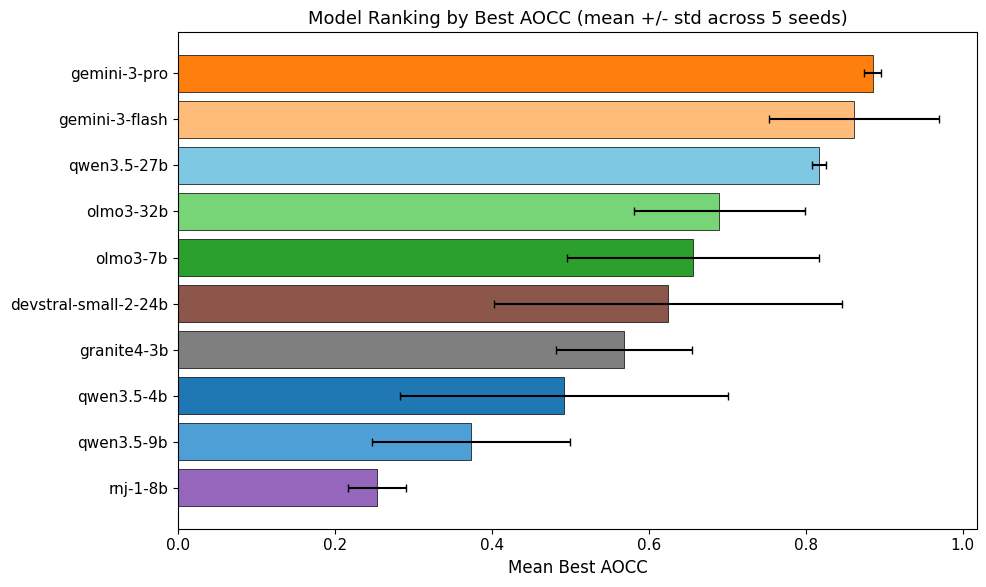

In [2]:
# --- Cell 2: Model Ranking Summary Table ---

# Best AOCC per seed
best_per_seed = df.groupby(["model", "seed"])["fitness"].max().reset_index()
best_per_seed.columns = ["model", "seed", "best_aocc"]
# Replace -inf with NaN for summary stats
best_per_seed["best_aocc"] = best_per_seed["best_aocc"].replace(-np.inf, np.nan)

# Failure rate per seed
fail_per_seed = df.groupby(["model", "seed"])["failed"].mean().reset_index()
fail_per_seed.columns = ["model", "seed", "failure_rate"]

# Summary table
summary = best_per_seed.groupby("model")["best_aocc"].agg(["mean", "std"]).reset_index()
summary.columns = ["model", "aocc_mean", "aocc_std"]

fail_summary = fail_per_seed.groupby("model")["failure_rate"].agg(["mean", "std"]).reset_index()
fail_summary.columns = ["model", "fail_mean", "fail_std"]

time_summary = timing_df.groupby("model")["wall_hours"].agg(["mean", "std"]).reset_index()
time_summary.columns = ["model", "hours_mean", "hours_std"]

summary = summary.merge(fail_summary, on="model").merge(time_summary, on="model")
summary["family"] = summary["model"].map(lambda m: MODELS[m]["family"])
summary["size"] = summary["model"].map(lambda m: MODELS[m]["size"])
summary = summary.sort_values("aocc_mean", ascending=False).reset_index(drop=True)

# Display
display_cols = summary[["model", "family", "size", "aocc_mean", "aocc_std", "fail_mean", "fail_std", "hours_mean", "hours_std"]].copy()
display_cols.columns = ["Model", "Family", "Size", "Best AOCC (mean)", "Best AOCC (std)",
                         "Failure Rate (mean)", "Failure Rate (std)",
                         "Wall Time h (mean)", "Wall Time h (std)"]
display(display_cols.style.format({
    "Best AOCC (mean)": "{:.4f}", "Best AOCC (std)": "{:.4f}",
    "Failure Rate (mean)": "{:.3f}", "Failure Rate (std)": "{:.3f}",
    "Wall Time h (mean)": "{:.2f}", "Wall Time h (std)": "{:.2f}",
}).bar(subset=["Best AOCC (mean)"], color="#5fba7d"))

# Horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6))
models_sorted = summary["model"].tolist()
y_pos = np.arange(len(models_sorted))
colors = [MODEL_COLORS[m] for m in models_sorted]
ax.barh(y_pos, summary["aocc_mean"], xerr=summary["aocc_std"],
        color=colors, edgecolor="black", linewidth=0.5, capsize=3)
ax.set_yticks(y_pos)
ax.set_yticklabels(models_sorted)
ax.set_xlabel("Mean Best AOCC")
ax.set_title("Model Ranking by Best AOCC (mean +/- std across 5 seeds)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

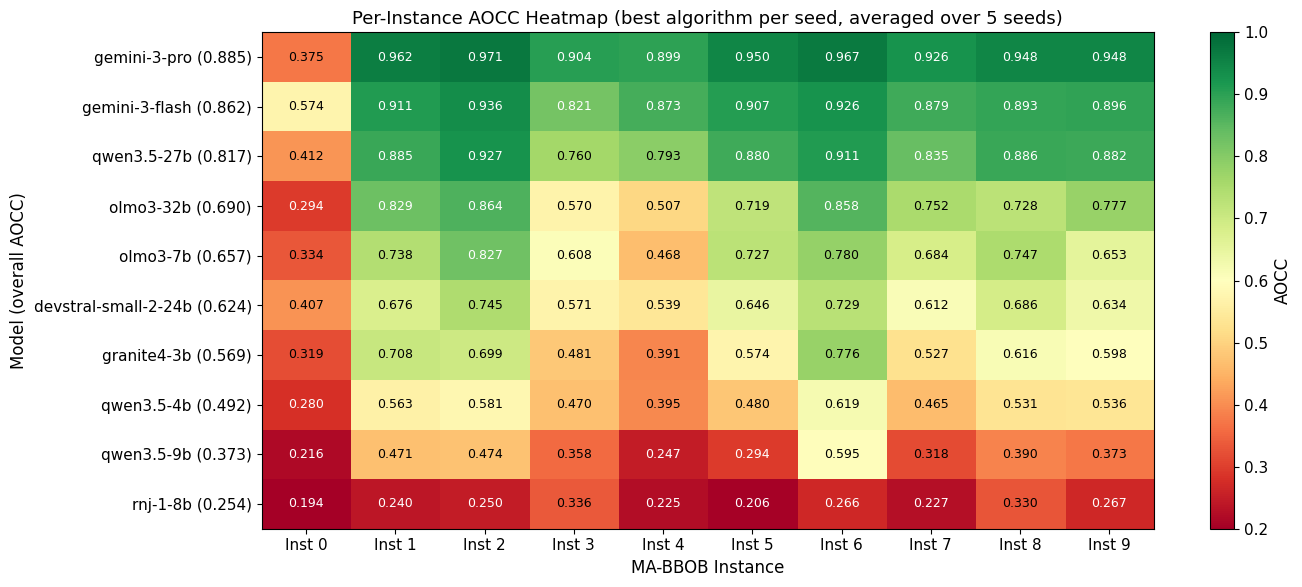


Mean AOCC per instance (averaged across models):
  Instance 0: 0.3404 (HARDEST)
  Instance 1: 0.6983
  Instance 2: 0.7275
  Instance 3: 0.5879
  Instance 4: 0.5336
  Instance 5: 0.6382
  Instance 6: 0.7427 (EASIEST)
  Instance 7: 0.6224
  Instance 8: 0.6754
  Instance 9: 0.6564


In [3]:
# --- Per-Instance AOCC Heatmap (averaged over best algorithm per seed) ---

# For each model & seed, find the best algorithm and get its per-instance AUCs
sorted_models = summary["model"].tolist()  # already sorted by aocc_mean desc

instance_matrix = []
instance_std_matrix = []
model_labels = []

for model in sorted_models:
    seed_instance_means = []
    for seed in range(N_SEEDS):
        sub = df[(df["model"] == model) & (df["seed"] == seed)]
        if sub.empty:
            continue
        # Find best candidate in this seed
        best_idx = sub["fitness"].idxmax()
        aucs = sub.loc[best_idx, "aucs"]
        if not aucs or len(aucs) != N_INSTANCES * EVAL_SEEDS:
            continue
        aucs_arr = np.array(aucs).reshape(N_INSTANCES, EVAL_SEEDS)
        seed_instance_means.append(aucs_arr.mean(axis=1))  # (10,)

    if seed_instance_means:
        stacked = np.array(seed_instance_means)  # (n_seeds, 10)
        instance_matrix.append(stacked.mean(axis=0))
        instance_std_matrix.append(stacked.std(axis=0))
        overall_mean = stacked.mean()
        model_labels.append(f"{model} ({overall_mean:.3f})")
    else:
        instance_matrix.append(np.full(N_INSTANCES, np.nan))
        instance_std_matrix.append(np.full(N_INSTANCES, np.nan))
        model_labels.append(f"{model} (N/A)")

instance_matrix = np.array(instance_matrix)
instance_std_matrix = np.array(instance_std_matrix)

fig, ax = plt.subplots(figsize=(14, max(6, len(sorted_models) * 0.6)))
im = ax.imshow(instance_matrix, aspect="auto", cmap="RdYlGn", vmin=0.2, vmax=1.0)

for i in range(instance_matrix.shape[0]):
    for j in range(instance_matrix.shape[1]):
        val = instance_matrix[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=9,
                    color="black" if 0.3 < val < 0.8 else "white")

ax.set_xticks(range(N_INSTANCES))
ax.set_xticklabels([f"Inst {i}" for i in range(N_INSTANCES)])
ax.set_yticks(range(len(model_labels)))
ax.set_yticklabels(model_labels)
ax.set_xlabel("MA-BBOB Instance")
ax.set_ylabel("Model (overall AOCC)")
ax.set_title("Per-Instance AOCC Heatmap (best algorithm per seed, averaged over 5 seeds)")
plt.colorbar(im, ax=ax, label="AOCC")
plt.tight_layout()
plt.show()

# Identify hard/easy instances
mean_per_instance = np.nanmean(instance_matrix, axis=0)
print("\nMean AOCC per instance (averaged across models):")
for i, m in enumerate(mean_per_instance):
    label = " (HARDEST)" if i == np.nanargmin(mean_per_instance) else \
            " (EASIEST)" if i == np.nanargmax(mean_per_instance) else ""
    print(f"  Instance {i}: {m:.4f}{label}")

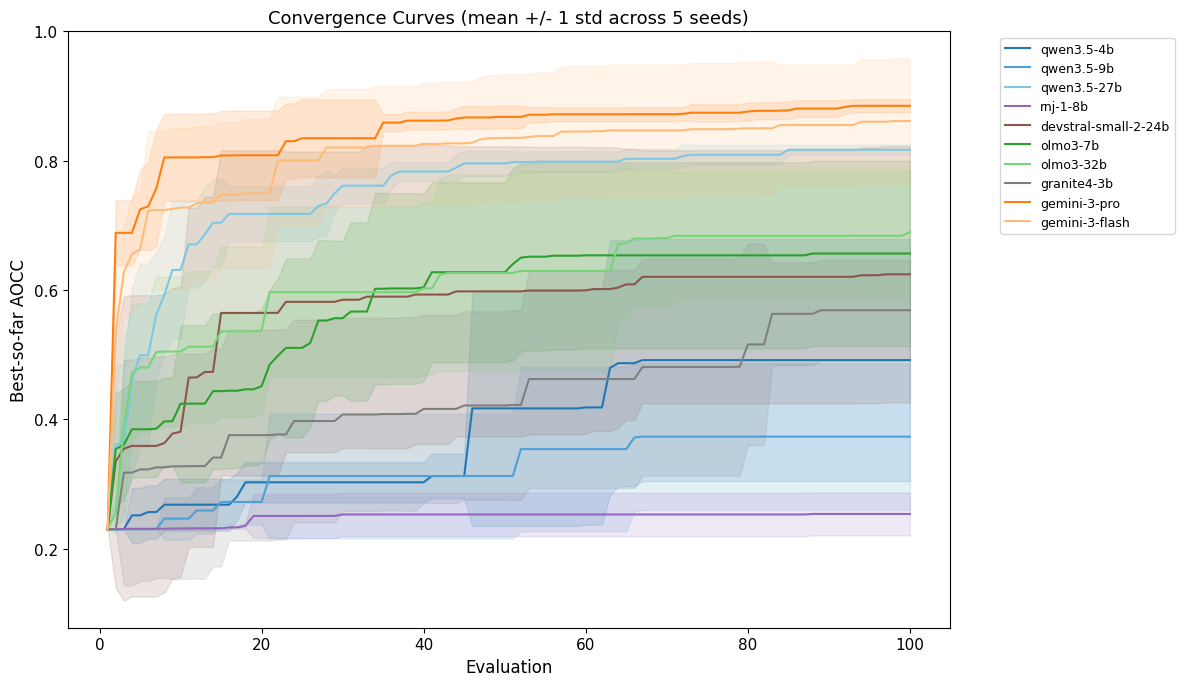

In [4]:
# --- Cell 3: Convergence Curves ---

def compute_best_so_far(model_tag):
    """Compute best-so-far AOCC curves across seeds."""
    curves = []
    for seed in range(N_SEEDS):
        sub = df[(df["model"] == model_tag) & (df["seed"] == seed)].sort_values("evaluation")
        fitness_vals = sub["fitness"].values.copy().astype(float)
        # Replace -inf with NaN, then forward-fill with cummax
        fitness_vals[np.isinf(fitness_vals) & (fitness_vals < 0)] = np.nan
        best_so_far = pd.Series(fitness_vals).expanding().max().values
        curves.append(best_so_far)
    # Pad to same length
    max_len = max(len(c) for c in curves) if curves else 0
    padded = []
    for c in curves:
        if len(c) < max_len:
            c = np.concatenate([c, np.full(max_len - len(c), c[-1] if len(c) > 0 else np.nan)])
        padded.append(c)
    return np.array(padded)

# Combined plot
fig, ax = plt.subplots(figsize=(12, 7))
for model_tag in MODELS:
    curves = compute_best_so_far(model_tag)
    if curves.size == 0:
        continue
    mean_curve = np.nanmean(curves, axis=0)
    std_curve = np.nanstd(curves, axis=0)
    x = np.arange(1, len(mean_curve) + 1)
    color = MODEL_COLORS[model_tag]
    ax.plot(x, mean_curve, label=model_tag, color=color, linewidth=1.5)
    ax.fill_between(x, mean_curve - std_curve, mean_curve + std_curve, alpha=0.15, color=color)
ax.set_xlabel("Evaluation")
ax.set_ylabel("Best-so-far AOCC")
ax.set_title("Convergence Curves (mean +/- 1 std across 5 seeds)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

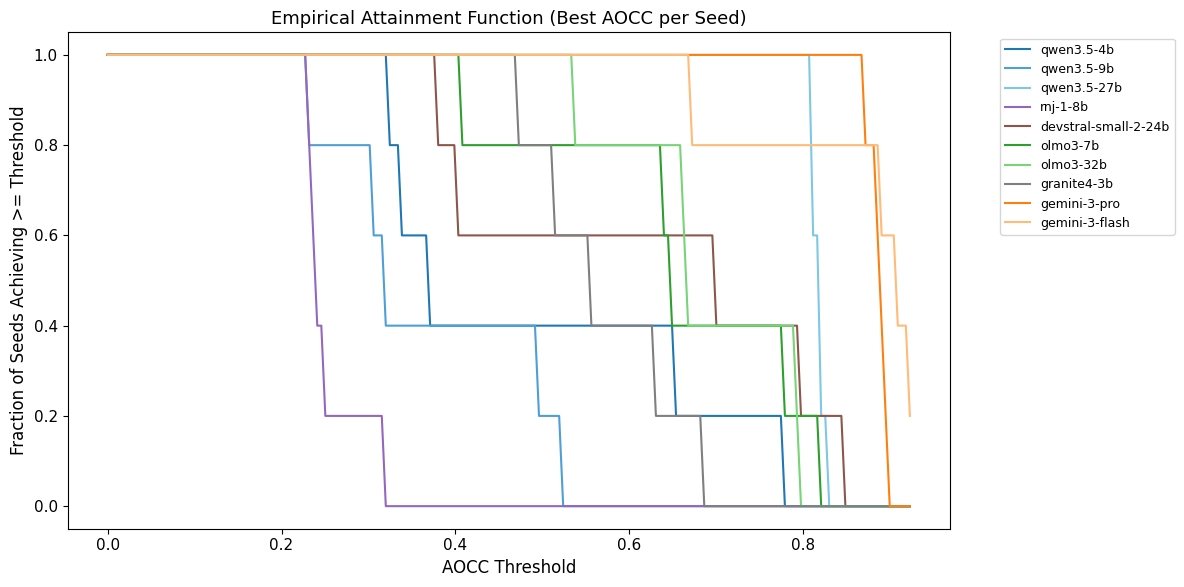

In [5]:
# --- Cell 4: Empirical Attainment Function / ECDF ---

# Collect best AOCC per seed per model
best_per_seed_clean = best_per_seed.copy()

# Determine threshold range
all_best = best_per_seed_clean["best_aocc"].dropna()
if len(all_best) > 0:
    thresholds = np.linspace(0, all_best.max(), 200)
else:
    thresholds = np.linspace(0, 1, 200)

fig, ax = plt.subplots(figsize=(12, 6))
for model_tag in MODELS:
    vals = best_per_seed_clean[best_per_seed_clean["model"] == model_tag]["best_aocc"].values
    fractions = [np.mean(vals >= t) for t in thresholds]
    ax.plot(thresholds, fractions, label=model_tag, color=MODEL_COLORS[model_tag], linewidth=1.5)

ax.set_xlabel("AOCC Threshold")
ax.set_ylabel("Fraction of Seeds Achieving >= Threshold")
ax.set_title("Empirical Attainment Function (Best AOCC per Seed)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

Kruskal-Wallis H=38.6226, p=0.000013


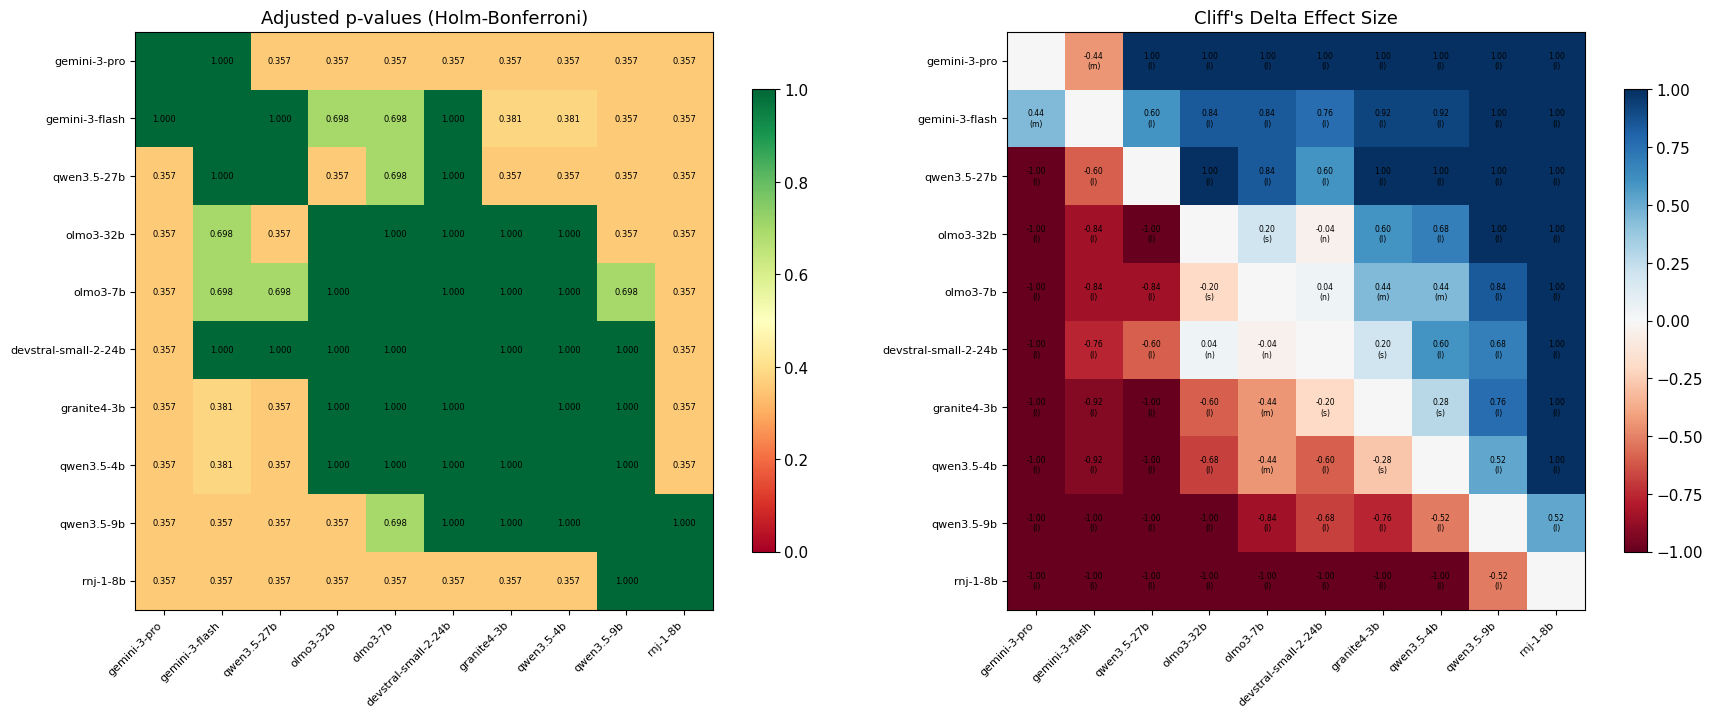


Bootstrap 95% CI for mean best AOCC:
  gemini-3-pro                  : 0.8851  [0.8752, 0.8932]
  gemini-3-flash                : 0.8615  [0.7637, 0.9188]
  qwen3.5-27b                   : 0.8171  [0.8102, 0.8237]
  olmo3-32b                     : 0.6899  [0.6114, 0.7684]
  olmo3-7b                      : 0.6567  [0.5288, 0.7730]
  devstral-small-2-24b          : 0.6245  [0.4510, 0.7979]
  granite4-3b                   : 0.5689  [0.5029, 0.6381]
  qwen3.5-4b                    : 0.4918  [0.3411, 0.6650]
  qwen3.5-9b                    : 0.3734  [0.2774, 0.4715]
  rnj-1-8b                      : 0.2539  [0.2331, 0.2873]


In [6]:
# --- Cell 5: Statistical Testing ---

def cliffs_delta(x, y):
    n_x, n_y = len(x), len(y)
    more = sum(1 for xi in x for yi in y if xi > yi)
    less = sum(1 for xi in x for yi in y if xi < yi)
    return (more - less) / (n_x * n_y)


def cliffs_delta_label(d):
    d = abs(d)
    if d < 0.147:
        return "negligible"
    elif d < 0.33:
        return "small"
    elif d < 0.474:
        return "medium"
    else:
        return "large"


def bootstrap_ci(x, y, n_boot=10000, ci=0.95):
    rng = np.random.default_rng(42)
    diffs = []
    for _ in range(n_boot):
        bx = rng.choice(x, size=len(x), replace=True)
        by = rng.choice(y, size=len(y), replace=True)
        diffs.append(bx.mean() - by.mean())
    diffs = np.array(diffs)
    lo = np.percentile(diffs, (1 - ci) / 2 * 100)
    hi = np.percentile(diffs, (1 + ci) / 2 * 100)
    return lo, hi


model_list = summary["model"].tolist()  # sorted by AOCC desc
n_models = len(model_list)

# Gather best-AOCC arrays per model
model_best = {}
for m in model_list:
    vals = best_per_seed_clean[best_per_seed_clean["model"] == m]["best_aocc"].dropna().values
    model_best[m] = vals

# Kruskal-Wallis
groups = [model_best[m] for m in model_list if len(model_best[m]) > 0]
if len(groups) >= 2:
    kw_stat, kw_p = stats.kruskal(*groups)
    print(f"Kruskal-Wallis H={kw_stat:.4f}, p={kw_p:.6f}")
else:
    print("Not enough groups for Kruskal-Wallis")

# Pairwise Mann-Whitney U
p_matrix = np.ones((n_models, n_models))
d_matrix = np.zeros((n_models, n_models))
raw_pvals = []
pair_indices = []

for i in range(n_models):
    for j in range(i + 1, n_models):
        x, y = model_best[model_list[i]], model_best[model_list[j]]
        if len(x) < 2 or len(y) < 2:
            continue
        _, p = stats.mannwhitneyu(x, y, alternative="two-sided")
        raw_pvals.append(p)
        pair_indices.append((i, j))
        d = cliffs_delta(x, y)
        d_matrix[i, j] = d
        d_matrix[j, i] = -d

# Holm-Bonferroni correction
if raw_pvals:
    sorted_idx = np.argsort(raw_pvals)
    n_tests = len(raw_pvals)
    adjusted = np.ones(n_tests)
    for rank, idx in enumerate(sorted_idx):
        adjusted[idx] = min(raw_pvals[idx] * (n_tests - rank), 1.0)
    # Enforce monotonicity
    for rank in range(1, len(sorted_idx)):
        idx = sorted_idx[rank]
        prev_idx = sorted_idx[rank - 1]
        adjusted[idx] = max(adjusted[idx], adjusted[prev_idx])
    for k, (i, j) in enumerate(pair_indices):
        p_matrix[i, j] = adjusted[k]
        p_matrix[j, i] = adjusted[k]

# Heatmaps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# p-value heatmap
im1 = ax1.imshow(p_matrix, cmap="RdYlGn", vmin=0, vmax=1)
ax1.set_xticks(range(n_models))
ax1.set_yticks(range(n_models))
ax1.set_xticklabels(model_list, rotation=45, ha="right", fontsize=8)
ax1.set_yticklabels(model_list, fontsize=8)
ax1.set_title("Adjusted p-values (Holm-Bonferroni)")
for i in range(n_models):
    for j in range(n_models):
        if i != j:
            ax1.text(j, i, f"{p_matrix[i,j]:.3f}", ha="center", va="center", fontsize=6)
fig.colorbar(im1, ax=ax1, shrink=0.8)

# Effect size heatmap
im2 = ax2.imshow(d_matrix, cmap="RdBu", vmin=-1, vmax=1)
ax2.set_xticks(range(n_models))
ax2.set_yticks(range(n_models))
ax2.set_xticklabels(model_list, rotation=45, ha="right", fontsize=8)
ax2.set_yticklabels(model_list, fontsize=8)
ax2.set_title("Cliff's Delta Effect Size")
for i in range(n_models):
    for j in range(n_models):
        if i != j:
            label = cliffs_delta_label(d_matrix[i, j])
            ax2.text(j, i, f"{d_matrix[i,j]:.2f}\n({label[0]})", ha="center", va="center", fontsize=5.5)
fig.colorbar(im2, ax=ax2, shrink=0.8)

plt.tight_layout()
plt.show()

# Bootstrap CIs for each model's mean best AOCC
print("\nBootstrap 95% CI for mean best AOCC:")
for m in model_list:
    vals = model_best[m]
    if len(vals) >= 2:
        lo, hi = bootstrap_ci(vals, np.zeros(1), n_boot=10000)
        # CI for single group mean: bootstrap the mean directly
        rng = np.random.default_rng(42)
        boot_means = [rng.choice(vals, size=len(vals), replace=True).mean() for _ in range(10000)]
        lo = np.percentile(boot_means, 2.5)
        hi = np.percentile(boot_means, 97.5)
        print(f"  {m:30s}: {np.mean(vals):.4f}  [{lo:.4f}, {hi:.4f}]")
    else:
        print(f"  {m:30s}: insufficient data")

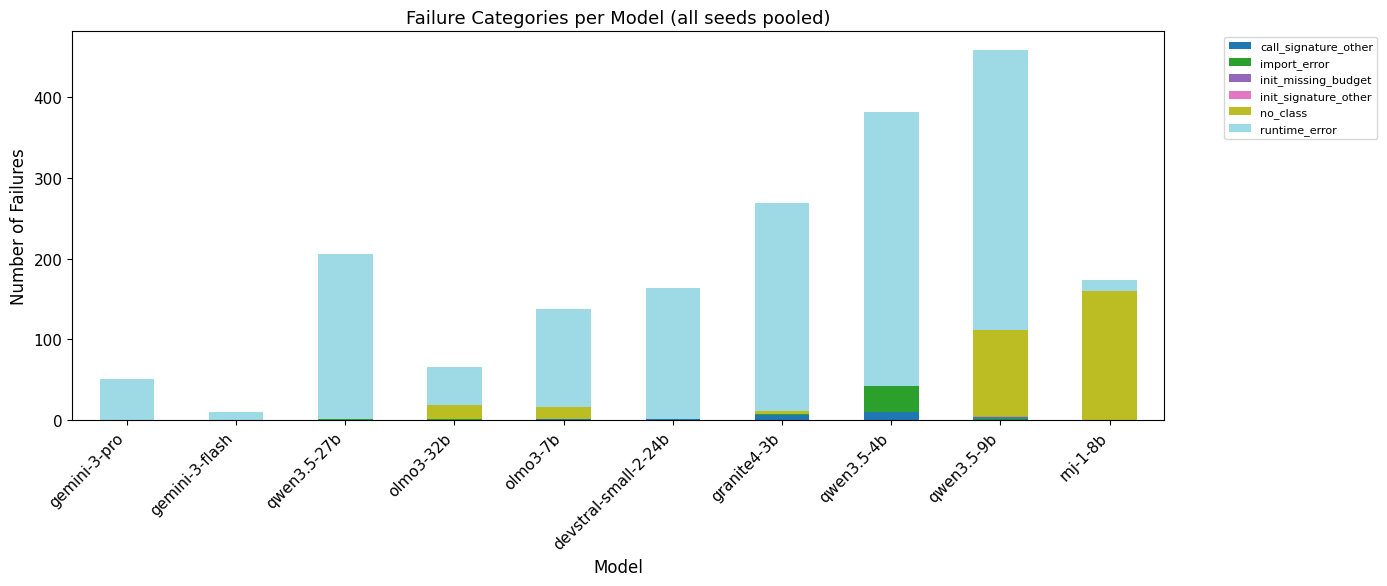

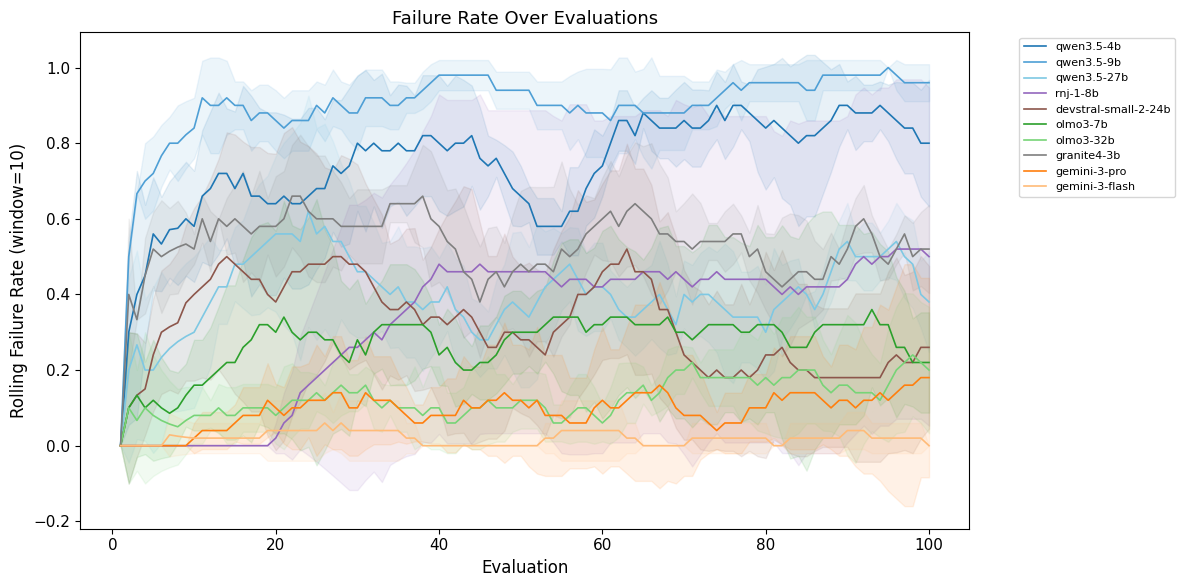


Top 3 Failure Types per Model:
  gemini-3-pro: runtime_error(51)
  gemini-3-flash: runtime_error(10)
  qwen3.5-27b: runtime_error(204), import_error(1)
  olmo3-32b: runtime_error(47), no_class(18), import_error(1)
  olmo3-7b: runtime_error(122), no_class(14), init_missing_budget(1)
  devstral-small-2-24b: runtime_error(162), call_signature_other(1)
  granite4-3b: runtime_error(258), call_signature_other(6), no_class(3)
  qwen3.5-4b: runtime_error(338), import_error(33), call_signature_other(10)
  qwen3.5-9b: runtime_error(346), no_class(107), import_error(3)
  rnj-1-8b: no_class(160), runtime_error(13)


In [7]:
# --- Cell 6: Failure Mode Analysis ---

# Categorize failures
failed_df = df[df["failed"]].copy()
failed_df["failure_type"] = failed_df.apply(categorize_failure, axis=1)

# Stacked bar chart of failure categories per model
failure_counts = failed_df.groupby(["model", "failure_type"]).size().unstack(fill_value=0)
# Reindex to include all models
failure_counts = failure_counts.reindex(summary["model"].tolist(), fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
failure_counts.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
ax.set_xlabel("Model")
ax.set_ylabel("Number of Failures")
ax.set_title("Failure Categories per Model (all seeds pooled)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Rolling failure rate over evaluations
window = 10
fig, ax = plt.subplots(figsize=(12, 6))
for model_tag in MODELS:
    rolling_rates = []
    for seed in range(N_SEEDS):
        sub = df[(df["model"] == model_tag) & (df["seed"] == seed)].sort_values("evaluation")
        if len(sub) == 0:
            continue
        rolling = sub["failed"].astype(float).rolling(window=window, min_periods=1).mean().values
        rolling_rates.append(rolling)
    if not rolling_rates:
        continue
    max_len = max(len(r) for r in rolling_rates)
    padded = [np.concatenate([r, np.full(max_len - len(r), np.nan)]) for r in rolling_rates]
    arr = np.array(padded)
    mean_r = np.nanmean(arr, axis=0)
    std_r = np.nanstd(arr, axis=0)
    x = np.arange(1, len(mean_r) + 1)
    color = MODEL_COLORS[model_tag]
    ax.plot(x, mean_r, label=model_tag, color=color, linewidth=1.2)
    ax.fill_between(x, mean_r - std_r, mean_r + std_r, alpha=0.1, color=color)
ax.set_xlabel("Evaluation")
ax.set_ylabel(f"Rolling Failure Rate (window={window})")
ax.set_title("Failure Rate Over Evaluations")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

# Top 3 error types per model
print("\nTop 3 Failure Types per Model:")
for m in summary["model"].tolist():
    sub = failed_df[failed_df["model"] == m]
    if len(sub) == 0:
        print(f"  {m}: no failures")
        continue
    top3 = sub["failure_type"].value_counts().head(3)
    types_str = ", ".join([f"{t}({c})" for t, c in top3.items()])
    print(f"  {m}: {types_str}")

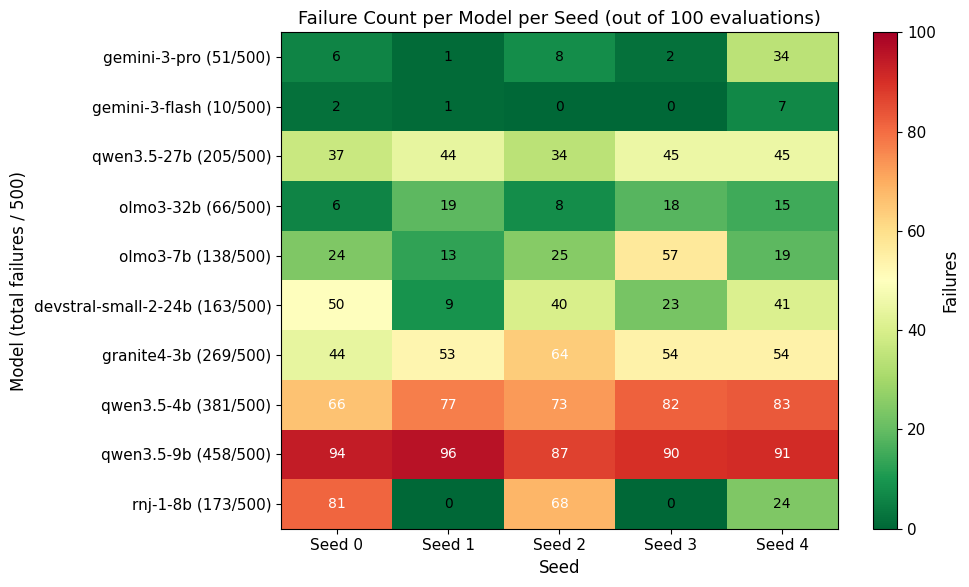


Seed-to-seed failure count variance:
  gemini-3-pro                  : 10 +/- 12  [6, 1, 8, 2, 34]
  gemini-3-flash                : 2 +/- 3  [2, 1, 0, 0, 7]
  qwen3.5-27b                   : 41 +/- 5  [37, 44, 34, 45, 45]
  olmo3-32b                     : 13 +/- 5  [6, 19, 8, 18, 15]
  olmo3-7b                      : 28 +/- 15  [24, 13, 25, 57, 19] ** HIGH VARIANCE
  devstral-small-2-24b          : 33 +/- 15  [50, 9, 40, 23, 41]
  granite4-3b                   : 54 +/- 6  [44, 53, 64, 54, 54]
  qwen3.5-4b                    : 76 +/- 6  [66, 77, 73, 82, 83]
  qwen3.5-9b                    : 92 +/- 3  [94, 96, 87, 90, 91]
  rnj-1-8b                      : 35 +/- 34  [81, 0, 68, 0, 24] ** HIGH VARIANCE


In [8]:
# --- Failure Count per Seed Heatmap ---

# Build failure count matrix: models (sorted by AOCC) × seeds
models_sorted = summary["model"].tolist()
fail_count_matrix = np.full((len(models_sorted), N_SEEDS), np.nan)

for i, model in enumerate(models_sorted):
    for seed in range(N_SEEDS):
        sub = df[(df["model"] == model) & (df["seed"] == seed)]
        if not sub.empty:
            fail_count_matrix[i, seed] = sub["failed"].sum()

model_labels = [f"{m} ({int(fail_count_matrix[i].sum())}/500)" for i, m in enumerate(models_sorted)]

fig, ax = plt.subplots(figsize=(10, max(6, len(models_sorted) * 0.55)))
im = ax.imshow(fail_count_matrix, aspect="auto", cmap="RdYlGn_r", vmin=0, vmax=BUDGET)

for i in range(fail_count_matrix.shape[0]):
    for j in range(fail_count_matrix.shape[1]):
        val = fail_count_matrix[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{int(val)}", ha="center", va="center", fontsize=10,
                    color="white" if val > 60 else "black")

ax.set_xticks(range(N_SEEDS))
ax.set_xticklabels([f"Seed {s}" for s in range(N_SEEDS)])
ax.set_yticks(range(len(model_labels)))
ax.set_yticklabels(model_labels)
ax.set_xlabel("Seed")
ax.set_ylabel("Model (total failures / 500)")
ax.set_title("Failure Count per Model per Seed (out of 100 evaluations)")
plt.colorbar(im, ax=ax, label="Failures")
plt.tight_layout()
plt.show()

# Flag high-variance models
print("\nSeed-to-seed failure count variance:")
for i, model in enumerate(models_sorted):
    counts = fail_count_matrix[i]
    valid = counts[~np.isnan(counts)]
    if len(valid) > 1:
        flag = " ** HIGH VARIANCE" if np.std(valid) > 15 else ""
        print(f"  {model:30s}: {np.mean(valid):.0f} +/- {np.std(valid):.0f}  "
              f"[{', '.join(f'{int(v)}' for v in valid)}]{flag}")

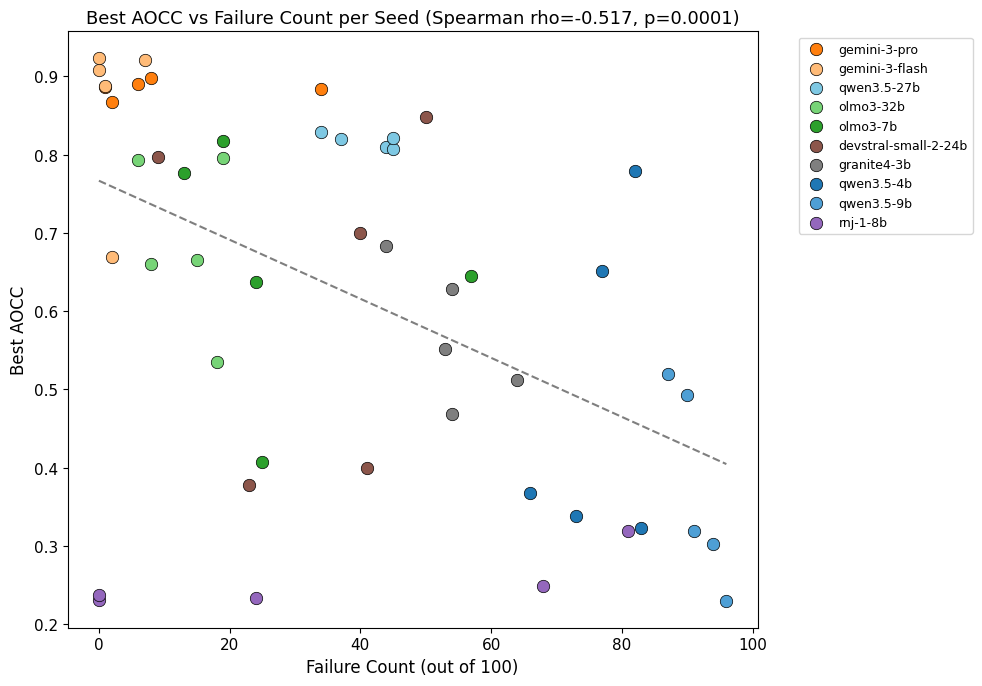

In [9]:
# --- Scatter: Best AOCC vs Failure Count per Seed ---

# Build per-seed data
scatter_rows = []
for model in summary["model"].tolist():
    for seed in range(N_SEEDS):
        sub = df[(df["model"] == model) & (df["seed"] == seed)]
        if sub.empty:
            continue
        best_aocc = sub["fitness"].max()
        if np.isinf(best_aocc) and best_aocc < 0:
            best_aocc = np.nan
        fail_count = int(sub["failed"].sum())
        scatter_rows.append({"model": model, "seed": seed, "best_aocc": best_aocc, "failures": fail_count})

scatter_df = pd.DataFrame(scatter_rows)

fig, ax = plt.subplots(figsize=(10, 7))
for model in summary["model"].tolist():
    sub = scatter_df[scatter_df["model"] == model]
    ax.scatter(sub["failures"], sub["best_aocc"], color=MODEL_COLORS[model],
               s=80, edgecolor="black", linewidth=0.5, label=model, zorder=5)

# Spearman correlation across all points
valid = scatter_df.dropna(subset=["best_aocc"])
rho, p = stats.spearmanr(valid["failures"], valid["best_aocc"])
ax.set_title(f"Best AOCC vs Failure Count per Seed (Spearman rho={rho:.3f}, p={p:.4f})")

# Trend line
z = np.polyfit(valid["failures"], valid["best_aocc"], 1)
x_line = np.linspace(valid["failures"].min(), valid["failures"].max(), 100)
ax.plot(x_line, np.polyval(z, x_line), "k--", alpha=0.5, linewidth=1.5)

ax.set_xlabel("Failure Count (out of 100)")
ax.set_ylabel("Best AOCC")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

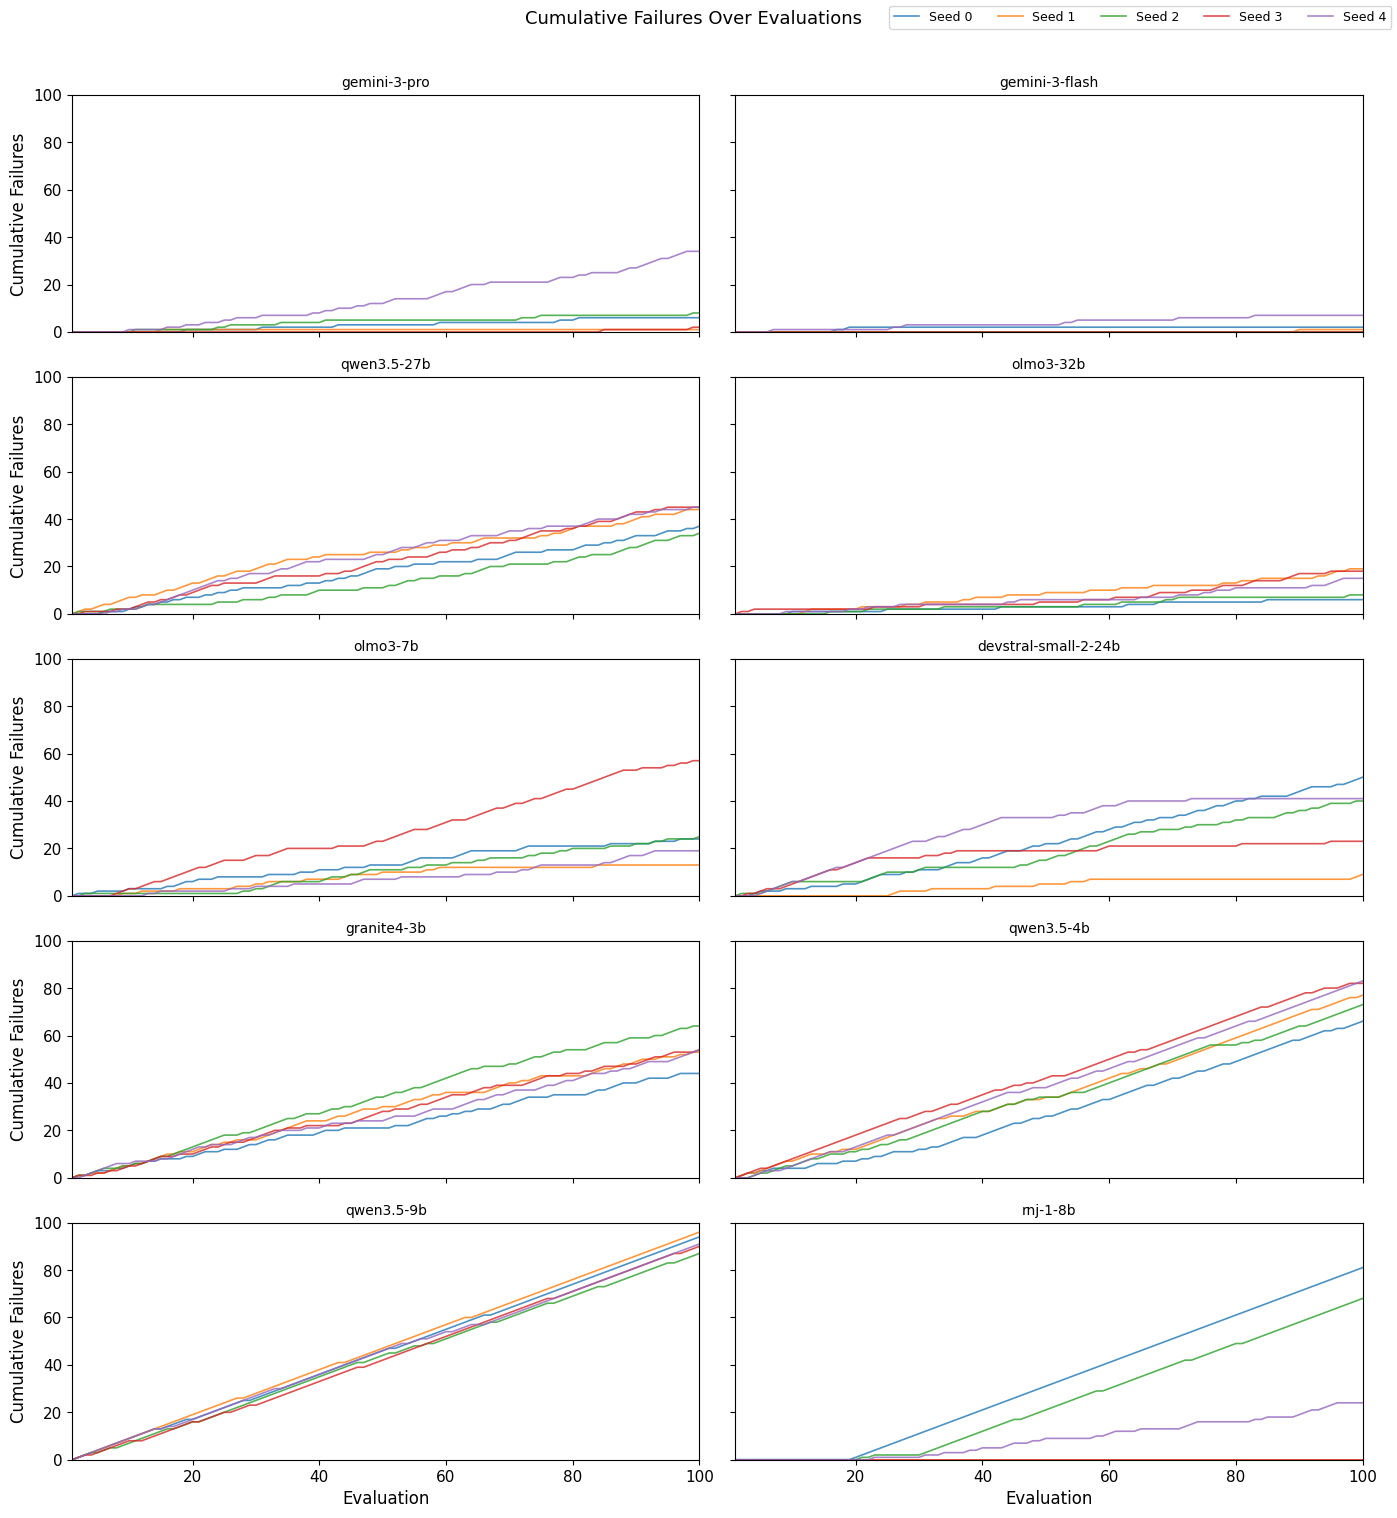

In [13]:
# --- Cumulative Failure Count per Seed (per model) ---

models_sorted = summary["model"].tolist()
n_cols = 2
n_rows = (len(models_sorted) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3), sharex=True, sharey=True)
axes = axes.flatten()

seed_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

for idx, model in enumerate(models_sorted):
    ax = axes[idx]
    for seed in range(N_SEEDS):
        sub = df[(df["model"] == model) & (df["seed"] == seed)].sort_values("evaluation")
        if sub.empty:
            continue
        cum_failures = sub["failed"].astype(int).cumsum().values
        evals = np.arange(1, len(cum_failures) + 1)
        ax.plot(evals, cum_failures, color=seed_colors[seed], linewidth=1.2,
                label=f"Seed {seed}", alpha=0.8)
    ax.set_title(model, fontsize=10)
    ax.set_ylim(0, BUDGET)
    ax.set_xlim(1, BUDGET)
    if idx >= (n_rows - 1) * n_cols:
        ax.set_xlabel("Evaluation")
    if idx % n_cols == 0:
        ax.set_ylabel("Cumulative Failures")

# Remove unused axes
for idx in range(len(models_sorted), len(axes)):
    axes[idx].set_visible(False)

# Single legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", fontsize=9, ncol=5)
fig.suptitle("Cumulative Failures Over Evaluations", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

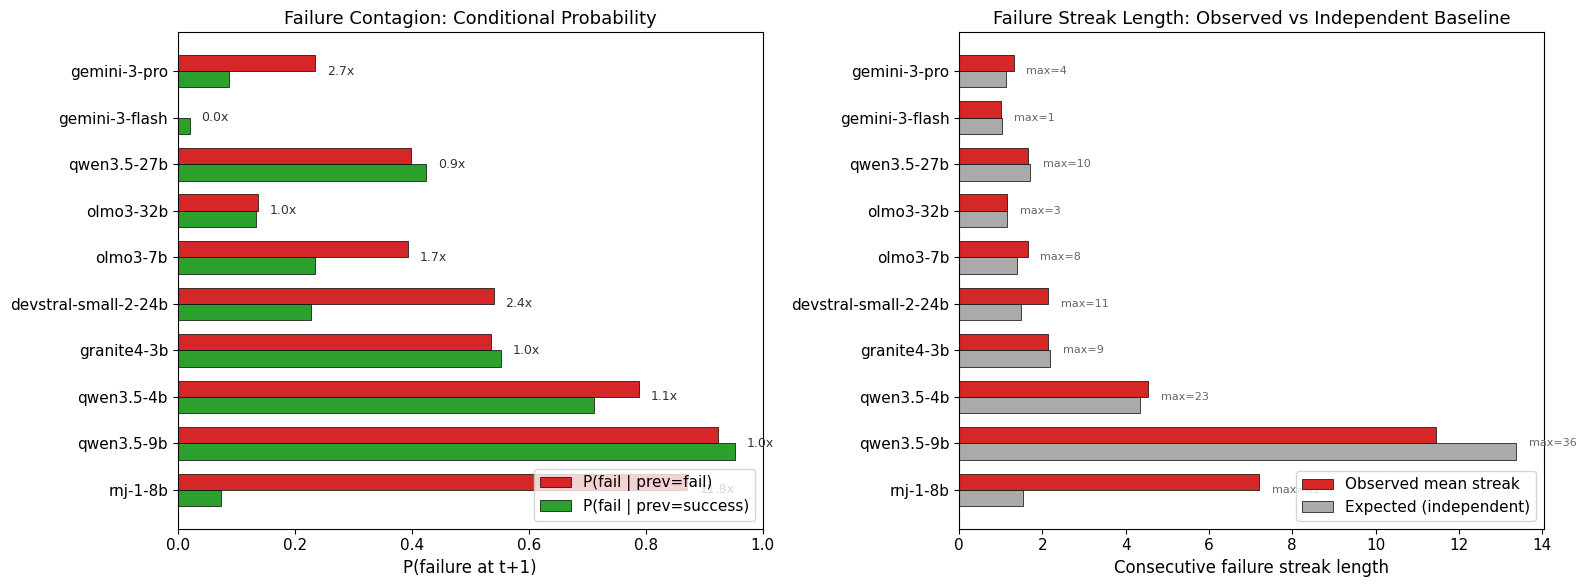

Failure Burstiness Summary:
                         Model   P(f|f)   P(f|s)   Lift  AvgStrk  ExpStrk  MaxStrk
                  gemini-3-pro    0.235    0.088    2.7      1.3      1.1        4
                gemini-3-flash    0.000    0.021    0.0      1.0      1.0        1
                   qwen3.5-27b    0.399    0.425    0.9      1.7      1.7       10
                     olmo3-32b    0.136    0.133    1.0      1.2      1.2        3
                      olmo3-7b    0.394    0.235    1.7      1.6      1.4        8
          devstral-small-2-24b    0.540    0.228    2.4      2.1      1.5       11
                   granite4-3b    0.536    0.553    1.0      2.1      2.2        9
                    qwen3.5-4b    0.788    0.712    1.1      4.5      4.3       23
                    qwen3.5-9b    0.923    0.952    1.0     11.4     13.4       36
                      rnj-1-8b    0.871    0.074   11.8      7.2      1.5       81


In [14]:
# --- Failure Burstiness Analysis ---
# Q: Is a model that just failed more likely to fail again?

# 1. Conditional probabilities per model
burst_rows = []
for model in summary["model"].tolist():
    after_fail, after_success = [], []
    streak_lengths = []
    for seed in range(N_SEEDS):
        sub = df[(df["model"] == model) & (df["seed"] == seed)].sort_values("evaluation")
        if len(sub) < 2:
            continue
        fails = sub["failed"].astype(int).values
        # Conditional probabilities
        for t in range(len(fails) - 1):
            if fails[t] == 1:
                after_fail.append(fails[t + 1])
            else:
                after_success.append(fails[t + 1])
        # Streak lengths
        streak = 0
        for f in fails:
            if f == 1:
                streak += 1
            elif streak > 0:
                streak_lengths.append(streak)
                streak = 0
        if streak > 0:
            streak_lengths.append(streak)

    p_fail_given_fail = np.mean(after_fail) if after_fail else np.nan
    p_fail_given_success = np.mean(after_success) if after_success else np.nan
    overall_rate = (len(after_fail) + sum(after_success == 1 for _ in [])) / max(1, len(after_fail) + len(after_success))
    # Proper overall rate
    all_next = after_fail + after_success
    overall_rate = np.mean(all_next) if all_next else np.nan

    # Expected mean streak length under independence: 1/(1-p) for geometric distribution
    p = overall_rate
    expected_mean_streak = 1 / (1 - p) if p < 1 else np.inf
    observed_mean_streak = np.mean(streak_lengths) if streak_lengths else 0

    burst_rows.append({
        "model": model,
        "P(fail|prev_fail)": p_fail_given_fail,
        "P(fail|prev_success)": p_fail_given_success,
        "overall_rate": overall_rate,
        "lift": p_fail_given_fail / p_fail_given_success if p_fail_given_success and p_fail_given_success > 0 else np.nan,
        "n_after_fail": len(after_fail),
        "n_after_success": len(after_success),
        "mean_streak": observed_mean_streak,
        "expected_streak": expected_mean_streak,
        "max_streak": max(streak_lengths) if streak_lengths else 0,
        "streak_lengths": streak_lengths,
    })

burst_df = pd.DataFrame(burst_rows)

# --- Plot 1: Conditional probability comparison ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

models_plot = burst_df["model"].tolist()
y_pos = np.arange(len(models_plot))
bar_h = 0.35

ax1.barh(y_pos - bar_h/2, burst_df["P(fail|prev_fail)"], bar_h,
         color="#d62728", edgecolor="black", linewidth=0.5, label="P(fail | prev=fail)")
ax1.barh(y_pos + bar_h/2, burst_df["P(fail|prev_success)"], bar_h,
         color="#2ca02c", edgecolor="black", linewidth=0.5, label="P(fail | prev=success)")

# Annotate lift
for i, row in burst_df.iterrows():
    if not np.isnan(row["lift"]):
        ax1.text(max(row["P(fail|prev_fail)"], row["P(fail|prev_success)"]) + 0.02, i,
                 f"{row['lift']:.1f}x", va="center", fontsize=9, color="#333")

ax1.set_yticks(y_pos)
ax1.set_yticklabels(models_plot)
ax1.set_xlabel("P(failure at t+1)")
ax1.set_title("Failure Contagion: Conditional Probability")
ax1.legend(loc="lower right")
ax1.invert_yaxis()

# --- Plot 2: Observed vs expected mean streak length ---
ax2.barh(y_pos - bar_h/2, burst_df["mean_streak"], bar_h,
         color="#d62728", edgecolor="black", linewidth=0.5, label="Observed mean streak")
ax2.barh(y_pos + bar_h/2, burst_df["expected_streak"].clip(upper=50), bar_h,
         color="#aaaaaa", edgecolor="black", linewidth=0.5, label="Expected (independent)")

for i, row in burst_df.iterrows():
    if row["max_streak"] > 0:
        ax2.text(max(row["mean_streak"], min(row["expected_streak"], 50)) + 0.3, i,
                 f"max={row['max_streak']}", va="center", fontsize=8, color="#666")

ax2.set_yticks(y_pos)
ax2.set_yticklabels(models_plot)
ax2.set_xlabel("Consecutive failure streak length")
ax2.set_title("Failure Streak Length: Observed vs Independent Baseline")
ax2.legend(loc="lower right")
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

# --- Summary table ---
print("Failure Burstiness Summary:")
print(f"{'Model':>30s}  {'P(f|f)':>7s}  {'P(f|s)':>7s}  {'Lift':>5s}  {'AvgStrk':>7s}  {'ExpStrk':>7s}  {'MaxStrk':>7s}")
for _, row in burst_df.iterrows():
    print(f"{row['model']:>30s}  {row['P(fail|prev_fail)']:>7.3f}  {row['P(fail|prev_success)']:>7.3f}  "
          f"{row['lift']:>5.1f}  {row['mean_streak']:>7.1f}  {row['expected_streak']:>7.1f}  {row['max_streak']:>7.0f}")

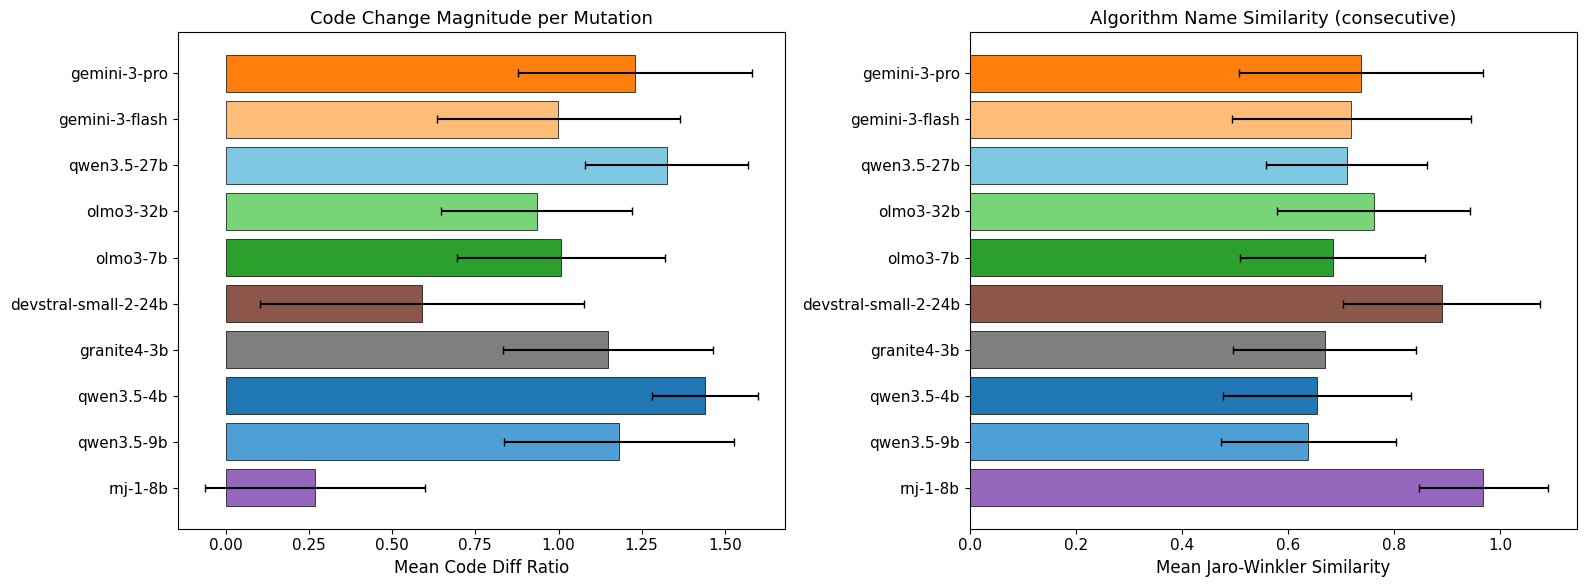

In [10]:
# --- Cell 7: Code Mutation Analysis ---

def jaro_winkler(s1, s2, p=0.1):
    if s1 == s2:
        return 1.0
    len1, len2 = len(s1), len(s2)
    if len1 == 0 or len2 == 0:
        return 0.0
    match_dist = max(len1, len2) // 2 - 1
    s1_matches = [False] * len1
    s2_matches = [False] * len2
    matches = 0
    transpositions = 0
    for i in range(len1):
        start = max(0, i - match_dist)
        end = min(i + match_dist + 1, len2)
        for j in range(start, end):
            if s2_matches[j] or s1[i] != s2[j]:
                continue
            s1_matches[i] = True
            s2_matches[j] = True
            matches += 1
            break
    if matches == 0:
        return 0.0
    k = 0
    for i in range(len1):
        if not s1_matches[i]:
            continue
        while not s2_matches[k]:
            k += 1
        if s1[i] != s2[k]:
            transpositions += 1
        k += 1
    jaro = (matches / len1 + matches / len2 + (matches - transpositions / 2) / matches) / 3
    prefix = 0
    for i in range(min(4, len1, len2)):
        if s1[i] == s2[i]:
            prefix += 1
        else:
            break
    return jaro + prefix * p * (1 - jaro)


def code_diff_ratio(code1, code2):
    """Compute fraction of lines changed between two code strings."""
    if not code1 or not code2:
        return 1.0
    lines1 = code1.splitlines()
    lines2 = code2.splitlines()
    diff = list(difflib.unified_diff(lines1, lines2, lineterm=""))
    changed = sum(1 for line in diff if line.startswith("+") or line.startswith("-"))
    # Subtract the header lines (--- and +++)
    changed = max(0, changed - 2)
    total = max(len(lines1), len(lines2), 1)
    return changed / total


# Build parent lookup by ID for lineage tracing
# Use evaluation index within each (model, seed) as proxy
diff_ratios_per_model = {}
name_sims_per_model = {}

for model_tag in MODELS:
    model_diffs = []
    model_name_sims = []
    for seed in range(N_SEEDS):
        sub = df[(df["model"] == model_tag) & (df["seed"] == seed)].sort_values("evaluation").reset_index(drop=True)
        if len(sub) < 2:
            continue
        seed_diffs = []
        seed_name_sims = []
        for idx in range(1, len(sub)):
            curr_code = sub.loc[idx, "code"] or ""
            prev_code = sub.loc[idx - 1, "code"] or ""
            seed_diffs.append(code_diff_ratio(prev_code, curr_code))
            curr_name = sub.loc[idx, "name"] or ""
            prev_name = sub.loc[idx - 1, "name"] or ""
            if curr_name and prev_name:
                seed_name_sims.append(jaro_winkler(prev_name, curr_name))
            else:
                seed_name_sims.append(np.nan)
        model_diffs.append(seed_diffs)
        model_name_sims.append(seed_name_sims)
    diff_ratios_per_model[model_tag] = model_diffs
    name_sims_per_model[model_tag] = model_name_sims

# Plot code diff ratios
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart: mean code diff ratio per model
model_mean_diff = {}
model_std_diff = {}
for m in summary["model"].tolist():
    all_diffs = [d for seed_diffs in diff_ratios_per_model.get(m, []) for d in seed_diffs]
    model_mean_diff[m] = np.mean(all_diffs) if all_diffs else 0
    model_std_diff[m] = np.std(all_diffs) if all_diffs else 0

models_plot = summary["model"].tolist()
y_pos = np.arange(len(models_plot))
means = [model_mean_diff[m] for m in models_plot]
stds = [model_std_diff[m] for m in models_plot]
colors = [MODEL_COLORS[m] for m in models_plot]
ax1.barh(y_pos, means, xerr=stds, color=colors, edgecolor="black", linewidth=0.5, capsize=3)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(models_plot)
ax1.set_xlabel("Mean Code Diff Ratio")
ax1.set_title("Code Change Magnitude per Mutation")
ax1.invert_yaxis()

# Bar chart: mean Jaro-Winkler name similarity per model
model_mean_jw = {}
model_std_jw = {}
for m in models_plot:
    all_sims = [s for seed_sims in name_sims_per_model.get(m, []) for s in seed_sims if not np.isnan(s)]
    model_mean_jw[m] = np.mean(all_sims) if all_sims else 0
    model_std_jw[m] = np.std(all_sims) if all_sims else 0

means_jw = [model_mean_jw[m] for m in models_plot]
stds_jw = [model_std_jw[m] for m in models_plot]
ax2.barh(y_pos, means_jw, xerr=stds_jw, color=colors, edgecolor="black", linewidth=0.5, capsize=3)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(models_plot)
ax2.set_xlabel("Mean Jaro-Winkler Similarity")
ax2.set_title("Algorithm Name Similarity (consecutive)")
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

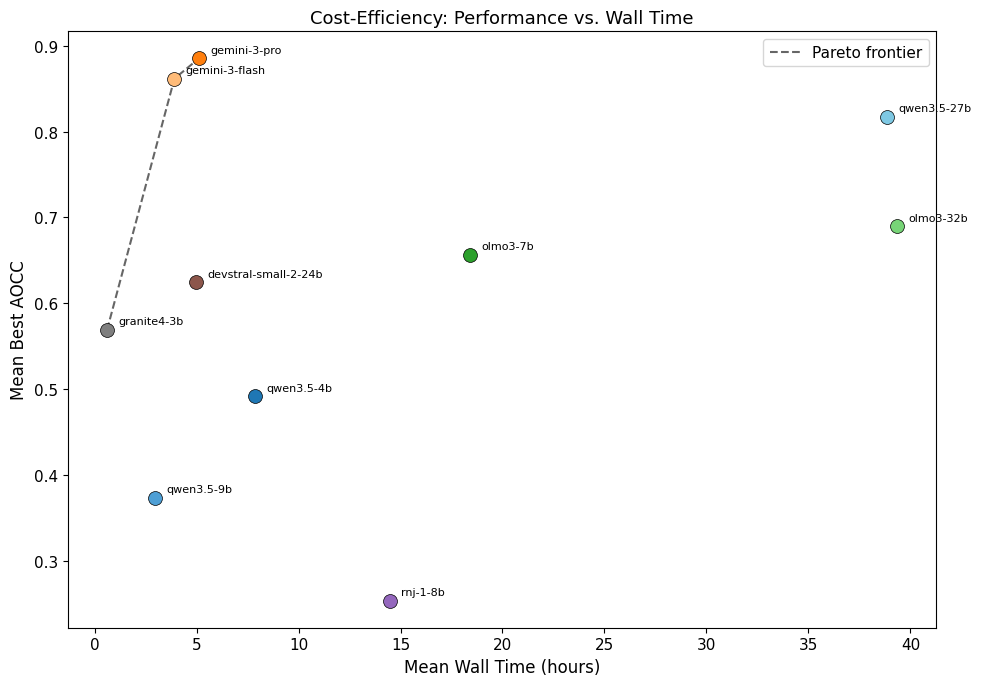

In [11]:
# --- Cell 8: Cost-Efficiency ---

# Merge timing with AOCC
eff = summary[["model", "aocc_mean", "hours_mean"]].copy()
eff = eff.dropna(subset=["hours_mean", "aocc_mean"])

fig, ax = plt.subplots(figsize=(10, 7))

for _, row in eff.iterrows():
    m = row["model"]
    ax.scatter(row["hours_mean"], row["aocc_mean"], color=MODEL_COLORS[m],
               s=100, edgecolor="black", linewidth=0.5, zorder=5)
    ax.annotate(m, (row["hours_mean"], row["aocc_mean"]),
                textcoords="offset points", xytext=(8, 4), fontsize=8)

# Pareto frontier
eff_sorted = eff.sort_values("hours_mean").reset_index(drop=True)
pareto = []
best_aocc = -np.inf
for _, row in eff_sorted.iterrows():
    if row["aocc_mean"] > best_aocc:
        pareto.append(row)
        best_aocc = row["aocc_mean"]
if pareto:
    pareto_df = pd.DataFrame(pareto)
    ax.plot(pareto_df["hours_mean"], pareto_df["aocc_mean"],
            "k--", linewidth=1.5, alpha=0.6, label="Pareto frontier")
    ax.legend()

ax.set_xlabel("Mean Wall Time (hours)")
ax.set_ylabel("Mean Best AOCC")
ax.set_title("Cost-Efficiency: Performance vs. Wall Time")
plt.tight_layout()
plt.show()

In [12]:
# --- Cell 9: Final Ranking & Recommendations ---

print("=" * 70)
print("RANKING 1: By Performance (Mean Best AOCC, descending)")
print("=" * 70)
perf_rank = summary[["model", "family", "size", "aocc_mean", "aocc_std"]].copy()
perf_rank = perf_rank.sort_values("aocc_mean", ascending=False).reset_index(drop=True)
perf_rank.index += 1
perf_rank.index.name = "Rank"
print(perf_rank.to_string(float_format=lambda x: f"{x:.4f}"))

print("\n")
print("=" * 70)
print("RANKING 2: By Reliability (Mean Failure Rate, ascending)")
print("=" * 70)
rel_rank = summary[["model", "family", "size", "fail_mean", "fail_std"]].copy()
rel_rank = rel_rank.sort_values("fail_mean", ascending=True).reset_index(drop=True)
rel_rank.index += 1
rel_rank.index.name = "Rank"
print(rel_rank.to_string(float_format=lambda x: f"{x:.4f}"))

print("\n")
print("=" * 70)
print("RANKING 3: By Efficiency (Mean Best AOCC / Wall Time Hours, descending)")
print("=" * 70)
eff_rank = summary[["model", "family", "size", "aocc_mean", "hours_mean"]].copy()
eff_rank["efficiency"] = eff_rank["aocc_mean"] / eff_rank["hours_mean"].replace(0, np.nan)
eff_rank = eff_rank.sort_values("efficiency", ascending=False).reset_index(drop=True)
eff_rank.index += 1
eff_rank.index.name = "Rank"
print(eff_rank.to_string(float_format=lambda x: f"{x:.4f}"))

print("\n")
print("=" * 70)
print("TOP-3 SHORTLIST FOR PHASE 2")
print("=" * 70)
top3 = perf_rank.head(3)
for _, row in top3.iterrows():
    fail_val = summary[summary["model"] == row["model"]]["fail_mean"].values[0]
    hours_val = summary[summary["model"] == row["model"]]["hours_mean"].values[0]
    print(f"  {row['model']:30s}  AOCC={row['aocc_mean']:.4f} +/- {row['aocc_std']:.4f}  "
          f"FailRate={fail_val:.3f}  WallTime={hours_val:.2f}h")

RANKING 1: By Performance (Mean Best AOCC, descending)
                     model    family    size  aocc_mean  aocc_std
Rank                                                             
1             gemini-3-pro    Gemini     API     0.8851    0.0113
2           gemini-3-flash    Gemini     API     0.8615    0.1082
3              qwen3.5-27b      Qwen  24-27B     0.8171    0.0090
4                olmo3-32b      OLMo  30-32B     0.6899    0.1086
5                 olmo3-7b      OLMo    7-9B     0.6567    0.1602
6     devstral-small-2-24b  Devstral  24-27B     0.6245    0.2218
7              granite4-3b   Granite    3-4B     0.5689    0.0868
8               qwen3.5-4b      Qwen    3-4B     0.4918    0.2091
9               qwen3.5-9b      Qwen    7-9B     0.3734    0.1267
10                rnj-1-8b       RnJ    7-9B     0.2539    0.0370


RANKING 2: By Reliability (Mean Failure Rate, ascending)
                     model    family    size  fail_mean  fail_std
Rank                        